# Standard scalling 

Scalling data between 0 and 1 
## Formula
z = (x - mean) / std 
This formula also known as z score normalization

In [32]:
# import libraries
import pandas as pd
from sklearn.preprocessing import StandardScaler, MinMaxScaler, MaxAbsScaler, RobustScaler

In [33]:
# Dataset
df = {
    "age": [25, 30, 35, 40, 45],
    "height": [125, 150, 170, 180, 100],
    "weight": [50, 60, 70, 80, 90]
}

# Create a DataFrame
df = pd.DataFrame(df)
# Display the original DataFrame
print("Original DataFrame:")
print(df) 

Original DataFrame:
   age  height  weight
0   25     125      50
1   30     150      60
2   35     170      70
3   40     180      80
4   45     100      90


In [26]:
# import the scallar
scalar = StandardScaler()
# Fit the data
scaled_df = scalar.fit_transform(df)

# Convert the scaled data back to a DataFrame
scaled_df = pd.DataFrame(scaled_df, columns=df.columns)
scaled_df.head()

,age,height,weight
0,-1.414214,-0.681994,-1.414214
1,-0.707107,0.170499,-0.707107
2,0.000000,0.852493,0.000000
3,0.707107,1.193490,0.707107
4,1.414214,-1.534487,1.414214


# Min max scalar 

In [29]:
# import the scallar
scalar = MinMaxScaler()
# Fit the data
scaled_df = scalar.fit_transform(df)

# Convert the scaled data back to a DataFrame
scaled_df = pd.DataFrame(scaled_df, columns=df.columns)
scaled_df.head()

,age,height,weight
0,0.00,0.3125,0.00
1,0.25,0.6250,0.25
2,0.50,0.8750,0.50
3,0.75,1.0000,0.75
4,1.00,0.0000,1.00


# Max absolute scalar

In [30]:
# import the scallar
scalar = MaxAbsScaler()
# Fit the data
scaled_df = scalar.fit_transform(df)

# Convert the scaled data back to a DataFrame
scaled_df = pd.DataFrame(scaled_df, columns=df.columns)
scaled_df.head()

,age,height,weight
0,0.555556,0.694444,0.555556
1,0.666667,0.833333,0.666667
2,0.777778,0.944444,0.777778
3,0.888889,1.000000,0.888889
4,1.000000,0.555556,1.000000


# Robust Scalar

In [34]:
# import the scallar
scalar = RobustScaler()
# Fit the data
scaled_df = scalar.fit_transform(df)

# Convert the scaled data back to a DataFrame
scaled_df = pd.DataFrame(scaled_df, columns=df.columns)
scaled_df.head()

,age,height,weight
0,-1.0,-0.555556,-1.0
1,-0.5,0.000000,-0.5
2,0.0,0.444444,0.0
3,0.5,0.666667,0.5
4,1.0,-1.111111,1.0


----
# Tramsformation

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [56]:
# Generate non-normal data (exponential distribution)
np.random.seed(0)
df = np.random.exponential(scale=2.0, size=(1000))
df = pd.DataFrame(df, columns=['values'])
df.head()
df.shape

(1000, 1)

<Axes: ylabel='Count'>

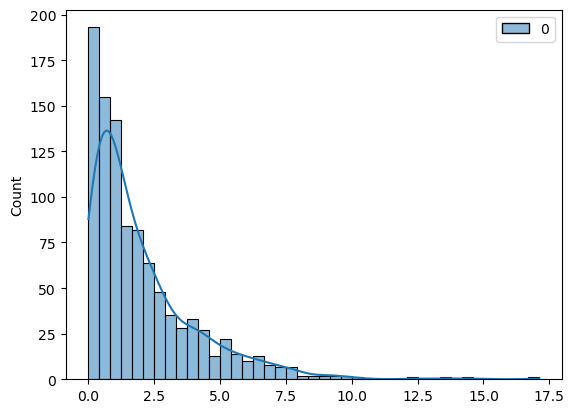

In [55]:
sns.histplot(df, kde=True)

In [61]:
from sklearn.preprocessing import PowerTransformer 
from sklearn.preprocessing import QuantileTransformer

pt_boxcox = PowerTransformer(method='box-cox') # data must be positive
pt_yeo = PowerTransformer(method='yeo-johnson')
pt_normal = QuantileTransformer(output_distribution='normal')

df['BoxCox'] = pt_boxcox.fit_transform(df[['values']] + 1) # add 1 to make data positive
df['YeoJohnson'] = pt_yeo.fit_transform(df[['values']])
df['QuantileNormal'] = pt_normal.fit_transform(df[['values']])

In [59]:
df.head()

,values,BoxCox,YeoJohnson
0,1.591749,0.179335,0.179335
1,2.511862,0.677331,0.677331
2,1.846446,0.339698,0.339698
3,1.574402,0.167607,0.167607
4,1.102097,-0.202107,-0.202107


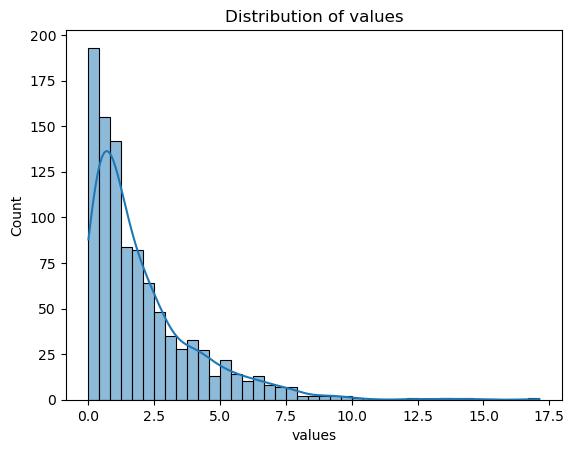

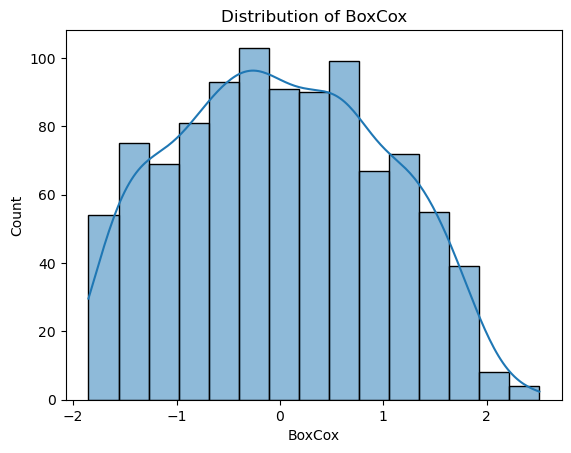

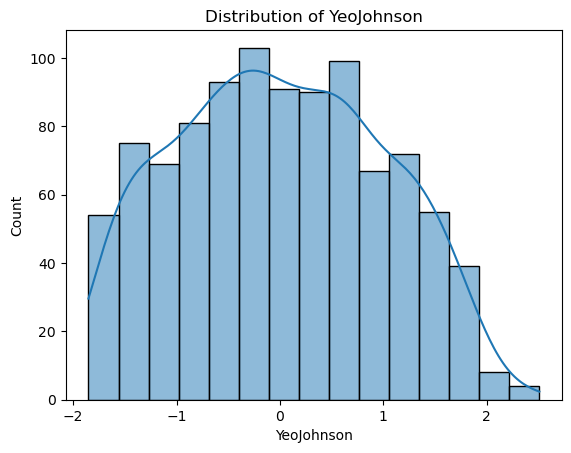

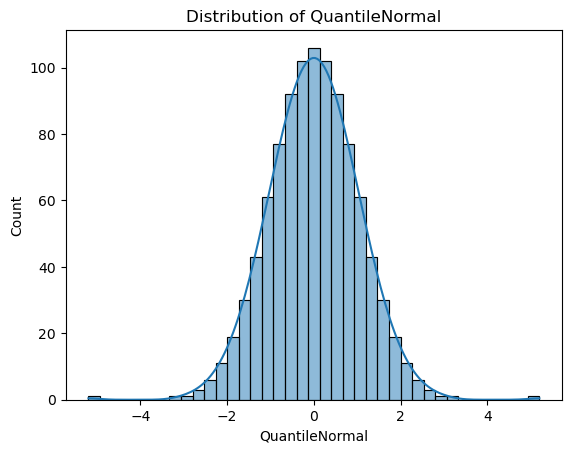

In [62]:
# Create histograms to compare distributions 
for col in df.columns:
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.show()

# Video 21 end 